# Testing
## Bevölkerung nach Geburtsort und Geburtsland
Datum: 21.01.2022

### Settings

#### Importiere die notwendigen Packages

In [2]:
#pip install geopandas altair fiona requests folium mplleaflet contextily seaborn datetime plotly

In [1]:
import pandas as pd
import pivottablejs
from pivottablejs import pivot_ui
import numpy as np
import altair as alt
import matplotlib.pyplot as plt
from datetime import datetime
import geopandas as gpd
import folium 
import requests

import datetime
import time

In [2]:
import plotly.express as px


Definiere Settings. Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen), 

In [46]:
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

In [47]:
now = datetime.date.today()
date_today = now.strftime("%Y-%m-%d")

#### Datenimport

**Dataset auf INTEG Datenkatalog**: https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_bestand_jahr_gemeinde_land_geburtsort_od3380

**Dataset auf PROD Datenkatalog**: https://data.stadt-zuerich.ch/dataset/bev_bestand_jahr_gemeinde_land_geburtsort_od3380


In [48]:
#Die Datasets sind nur zum Testen auf INT-DWH-Dropzone. Wenn der Test vorbei ist, sind sie auf PROD. 
# Über den Status kann man einfach switchen

status = "prod";
print(status)

prod


In [49]:
# Filepath
if status == "prod":
    fp = r"//szh.loc/ssz/applikationen/OGD_Dropzone/DWH/bev_bestand_jahr_gemeinde_land_geburtsort_od3380/BEV338OD3380.csv"
else:
    fp = r"//szh.loc/ssz/applikationen/OGD_Dropzone/INT_DWH/bev_bestand_jahr_gemeinde_land_geburtsort_od3380/BEV338OD3380.csv"
#download from INT-Datacatalog:
# https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bfs_bevreg_todesursache-aggregiert_alter_geschlecht_seit1995_od3120/download/BEV312OD3120.csv
print(fp)

//szh.loc/ssz/applikationen/OGD_Dropzone/DWH/bev_bestand_jahr_gemeinde_land_geburtsort_od3380/BEV338OD3380.csv


In [50]:
# Read the data
data2betested = pd.read_csv(
    fp, 
    sep=',',
    parse_dates=True,
    #date_parser=lambda x: pd.to_datetime(x, format="%Y"), 
    #index_col="date_time",
    low_memory=False    
    )

#### Basic Tests

In der Folge ein paar erste Tests:

In [51]:
#type(data2betested)

 - 1) Zeige eine kurze Vorschau der importierten Daten
 - 2) Weise die Datentypen aus
 - 3) Zeige die Shape (Umfang) des Datensatzes an

In [52]:
data2betested.head(1)

,StichtagDatJahr,xkoord,ykoord,GebOrtSort,GebOrtLang,GebLandSort,GebLandLang,AnzBestWir
0,2020,2679530,1236588,1,Aeugst am Albis,8100,Schweiz,6


In [53]:
data2betested.dtypes

StichtagDatJahr      int64
xkoord             float64
ykoord             float64
GebOrtSort           int64
GebOrtLang          object
GebLandSort          int64
GebLandLang         object
AnzBestWir           int64
dtype: object

In [54]:
data2betested.shape

(1696, 8)

Beschreibe einzelne Attribute

In [55]:
data2betested.describe()

,StichtagDatJahr,xkoord,ykoord,GebOrtSort,GebLandSort,AnzBestWir
count,1696,1487,1487,1696,1696,1696
mean,2020,2654437,1214251,3707,8136,256
std,0,61281,47532,2979,106,3301
min,2020,2495123,1076471,1,8100,0
25%,2020,2611483,1183438,1058,8100,2
50%,2020,2655114,1226016,3312,8100,5
75%,2020,2698298,1252343,5173,8100,18
max,2020,2826234,1291100,9999,8995,126647


#### In diesem Datensatz insbesondere Missings bei Koordinaten?

Wie viele Nullwerte gibt es im Datensatz?

In [56]:
data2betested.isnull().sum()

StichtagDatJahr      0
xkoord             209
ykoord             209
GebOrtSort           0
GebOrtLang           0
GebLandSort          0
GebLandLang          0
AnzBestWir           0
dtype: int64

Viele Missings stammen daher, dass wir keine Koordinaten zu Ländern haben. Aus der Schweiz sollte es aber keine geben...

In [57]:
ch_missings = data2betested.query('GebLandLang=="Schweiz"')
ch_missings[ch_missings['xkoord'].isna()]

,StichtagDatJahr,xkoord,ykoord,GebOrtSort,GebOrtLang,GebLandSort,GebLandLang,AnzBestWir
629,2020,NaN,NaN,2430,Welschenrohr-Gänsbrunnen,8100,Schweiz,15
911,2020,NaN,NaN,3715,Muntogna da Schons,8100,Schweiz,1
1306,2020,NaN,NaN,5399,Verzasca,8100,Schweiz,1


**Achtung**

Wenn es hier Missings hat, dann bedeutet das, dass im SASA-Job wohl nicht die aktuellsten Koordinatenwerte übernommen wurden. Diese müssen jedes Jahr ca. Ende Januar von der Swisstopo aufbereitet werden. Bei uns macht das Mario, für die Gemeindegrenzen.


### Zwischenschritt optional - aktuellste Koordinaten für SASA generieren

Im folgenden generiere ich die notwendigen Gemeindemittelpunkte für SASA.

In [26]:
geo_path =r"//szh.loc/ssz/data/GIS/Daten/Vektor/_aktuell/swisstopo/swissBOUNDARIES3d_lv95/swissBOUNDARIES3D_1_3_TLM_HOHEITSGEBIET.shp"
geo_path_bfs_data =r"\\szh\ssz\data\GIS\Daten\Vektor\2022\schweizer_gemeindegrenzen_mit_bfs_raumgliederung_2022.shp"

imp_gdf_gemeindegrenzen = gpd.read_file(geo_path)
imp_gdf_gemeindegrenzen.head(2)
imp_gdf_gemeindegrenzen.dtypes

imp_gdf_bfs_gemeindegrenzen = gpd.read_file(geo_path_bfs_data)


<AxesSubplot:>

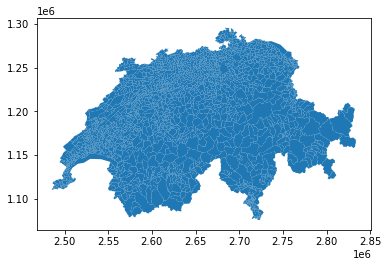

In [18]:
imp_gdf_gemeindegrenzen.plot()

<AxesSubplot:>

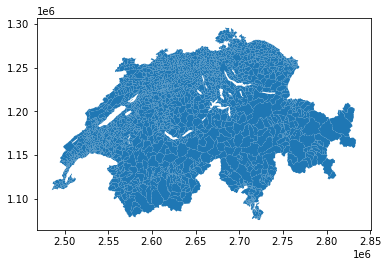

In [27]:
imp_gdf_bfs_gemeindegrenzen.plot()

In [16]:
#Gibt es bereits ein CRS? --> Ja
imp_gdf_gemeindegrenzen.crs is None

False

In [28]:
imp_gdf_bfs_gemeindegrenzen.crs is None

False

In [17]:
imp_gdf_gemeindegrenzen.crs

<Compound CRS: COMPD_CS["CH1903+ / LV95 + LN02 height",PROJCS["CH ...>
Name: CH1903+ / LV95 + LN02 height
Axis Info [cartesian|vertical]:
- [east]: Easting (metre)
- [north]: Northing (metre)
- [up]: Gravity-related height (metre)
Area of Use:
- undefined
Datum: CH1903+
- Ellipsoid: Bessel 1841
- Prime Meridian: Greenwich
Sub CRS:
- CH1903+ / LV95
- LN02 height

In [29]:
imp_gdf_bfs_gemeindegrenzen.crs

<Projected CRS: EPSG:2056>
Name: CH1903+ / LV95
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Liechtenstein; Switzerland.
- bounds: (5.96, 45.82, 10.49, 47.81)
Coordinate Operation:
- name: Swiss Oblique Mercator 1995
- method: Hotine Oblique Mercator (variant B)
Datum: CH1903+
- Ellipsoid: Bessel 1841
- Prime Meridian: Greenwich

#### Berechne die Centroid-Koordinaten aller Gemeinden

In [58]:
gdf_gemeindegrenzen=imp_gdf_gemeindegrenzen

gdf_gemeindegrenzen["X"] = gdf_gemeindegrenzen.centroid.x
gdf_gemeindegrenzen["Y"] = gdf_gemeindegrenzen.centroid.y
#gdf_gemeindegrenzen.head(2)

In [59]:
gdf_bfs_gemeindegrenzen = imp_gdf_bfs_gemeindegrenzen
gdf_bfs_gemeindegrenzen["X"] = gdf_bfs_gemeindegrenzen.centroid.x
gdf_bfs_gemeindegrenzen["Y"] = gdf_bfs_gemeindegrenzen.centroid.y
#gdf_gemeindegrenzen.head(2)

In [60]:
gdf_gemeindegrenzen.info
gdf_gemeindegrenzen.dtypes

UUID            object
DATUM_AEND      object
DATUM_ERST      object
ERSTELL_J        int64
ERSTELL_M       object
REVISION_J       int64
REVISION_M      object
GRUND_AEND      object
HERKUNFT        object
HERKUNFT_J       int64
HERKUNFT_M      object
OBJEKTART       object
BEZIRKSNUM     float64
SEE_FLAECH     float64
REVISION_Q      object
NAME            object
KANTONSNUM     float64
ICC             object
EINWOHNERZ     float64
BFS_NUMMER       int64
GEM_TEIL        object
GEM_FLAECH     float64
SHN             object
geometry      geometry
X              float64
Y              float64
dtype: object

In [61]:
gdf_bfs_gemeindegrenzen.info
gdf_bfs_gemeindegrenzen.dtypes

GMDHISTID        int64
GMDNR          float64
GMDNAME         object
BZHISTID       float64
BZNR           float64
KTNR           float64
GRNR           float64
AREA_HA        float64
E_MIN          float64
E_MAX          float64
N_MIN          float64
N_MAX          float64
E_CNTR         float64
N_CNTR         float64
Z_MIN          float64
Z_MAX          float64
Z_AVG          float64
Z_MED          float64
Z_CNTR         float64
2022_01_01      object
2022_01__1     float64
2022_01__2      object
2022_01__3     float64
2022_01__4      object
2022_01__5      object
2022_01__6      object
2022_01__7      object
2022_01__8      object
2022_01__9      object
2022_01_10      object
2022_01_11      object
2022_01_12      object
2022_01_13      object
2022_01_14      object
2022_01_15      object
2022_01_16      object
2022_01_17      object
geometry      geometry
X              float64
Y              float64
dtype: object

In [62]:
gdf_bfs_gemeindegrenzen[['GMDNR','GMDNAME','BZNR','KTNR','E_CNTR','N_CNTR','X', 'Y','AREA_HA']]

,GMDNR,GMDNAME,BZNR,KTNR,E_CNTR,N_CNTR,X,Y,AREA_HA
0,1,Aeugst am Albis,101,1,2679300,1235700,2679530,1236594,791
1,2,Affoltern am Albis,101,1,2676800,1236800,2676556,1237239,1059
2,3,Bonstetten,101,1,2677800,1241000,2677675,1241174,743
3,4,Hausen am Albis,101,1,2682900,1233100,2683137,1233183,1360
4,5,Hedingen,101,1,2676400,1239000,2676562,1239456,653
...,...,...,...,...,...,...,...,...,...
2146,6806,Vendlincourt,2603,26,2578200,1255600,2578150,1255708,915
2147,6807,Basse-Allaine,2603,26,2569300,1258900,2570130,1257814,2304
2148,6808,Clos du Doubs,2603,26,2579100,1246300,2575958,1244510,6175
2149,6809,Haute-Ajoie,2603,26,2567000,1249100,2564123,1248056,4093


In [63]:
exp_gdf_gemeindegrenzen = gdf_gemeindegrenzen[['X', 'Y','BFS_NUMMER','NAME','BEZIRKSNUM','KANTONSNUM','EINWOHNERZ','GEM_TEIL','GEM_FLAECH']]\
.query('GEM_TEIL == "0" or GEM_TEIL == "1"')

In [64]:
exp_gdf_gemeindegrenzen.sort_values('GEM_TEIL', ascending=False)

,X,Y,BFS_NUMMER,NAME,BEZIRKSNUM,KANTONSNUM,EINWOHNERZ,GEM_TEIL,GEM_FLAECH
867,2579880,1218026,756,Twann-Tüscherz,242,2,1163,1,1233
2082,2710257,1095295,5181,Curio,2105,21,565,1,275
143,2795974,1159231,3791,Zuoz,1846,18,1177,1,6578
146,2651000,1203002,1002,Entlebuch,316,3,3280,1,5690
1797,2632615,1169541,587,Matten bei Interlaken,250,2,4115,1,591
...,...,...,...,...,...,...,...,...,...
750,2594847,1221200,383,Büren an der Aare,243,2,3584,0,1260
749,2559371,1217879,441,Renan (BE),241,2,927,0,1263
748,2742819,1255574,3442,Gaiserwald,1721,17,8327,0,1263
747,2726413,1245166,3375,Oberhelfenschwil,1727,17,1251,0,1265


In [65]:
#Gibts noch n-Fache BFS-Nr?
test = exp_gdf_gemeindegrenzen.groupby(['BFS_NUMMER']).agg(AnzParts=('BFS_NUMMER', 'count')) 
#test.sort_values('AnzParts', ascending=False) 

In [66]:
exp_gdf_gemeindegrenzen.query('BFS_NUMMER == 5399')


,X,Y,BFS_NUMMER,NAME,BEZIRKSNUM,KANTONSNUM,EINWOHNERZ,GEM_TEIL,GEM_FLAECH
12,2705861,1128810,5399,Verzasca,2104,21,816,0,21848


In [67]:
exp_gdf_gemeindegrenzen.isnull().sum()

X               0
Y               0
BFS_NUMMER      0
NAME            0
BEZIRKSNUM    159
KANTONSNUM     13
EINWOHNERZ     17
GEM_TEIL        0
GEM_FLAECH      0
dtype: int64

#### Exportiere das File als Excel für SASA

Setze für das aktuelle Jahr bei den Daten den korrekten Wert ein

In [70]:
exp_jahr = "5000"

print(r"\\szh.loc\ssz\data\Auswertungen\Bevoelkerung\SASA\BEV338\gis_centroide_gemeinden\KOOR_"+exp_jahr+".xlsx")

\\szh.loc\ssz\data\Auswertungen\Bevoelkerung\SASA\BEV338\gis_centroide_gemeinden\KOOR_5000.xlsx


In [28]:

export_path =r"\\szh.loc\ssz\data\Auswertungen\Bevoelkerung\SASA\BEV338\gis_centroide_gemeinden\KOOR_"+exp_jahr+".xlsx"

In [29]:
exp_gdf_gemeindegrenzen.to_excel(export_path,index=False)

## Ältere Tests...

Importiere die Gemeindegrenzen der Schweiz und exportiere die Centroide dazu

<AxesSubplot:>

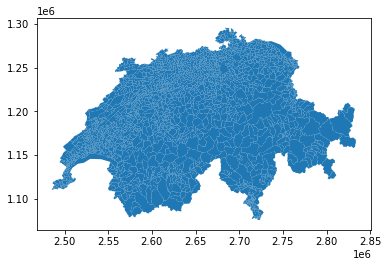

In [30]:
# Read abt. Geopandas https://geopandas.org/docs/user_guide/io.html
# Filepath statzonen
#\\szh.loc\ssz\data\GIS\Daten\Vektor\_aktuell\swisstopo\swissBOUNDARIES3d_lv95\swissBOUNDARIES3D_1_3_TLM_HOHEITSGEBIET.shp
input_gemeinden_CH = r"//szh.loc/ssz/data/GIS/Daten/Vektor/_aktuell/swisstopo/swissBOUNDARIES3d_lv95/swissBOUNDARIES3D_1_3_TLM_HOHEITSGEBIET.shp"
df_gemeinden_CH = gpd.read_file(input_gemeinden_CH)

df_gemeinden_CH.plot()
#df_stadtkreise.dtypes

In [31]:
#Berechne die Centroide

for i in range(0,len(df_gemeinden_CH)):
    df_gemeinden_CH.loc[i,'centroid_lon'] = df_gemeinden_CH.geometry.centroid.x.iloc[i]
    df_gemeinden_CH.loc[i,'centroid_lat'] = df_gemeinden_CH.geometry.centroid.y.iloc[i];
    
df_gemeinden_CH.head()   


,UUID,DATUM_AEND,DATUM_ERST,ERSTELL_J,ERSTELL_M,REVISION_J,REVISION_M,...,BFS_NUMMER,GEM_TEIL,GEM_FLAECH,SHN,geometry,centroid_lon,centroid_lat
0,{D5A9677C-FE38-44F6-B0E8-3177F6252C81},2020-11-03,2008-11-24,2000,1,2021,1,...,3762,0,43861,CH18433762,"POLYGON Z ((2812956.113 1194956.023 2980.122, ...",2816858,1184634
1,{B55F9EAE-EB69-4468-A41C-7BB28A6699EE},2020-11-03,2008-11-24,2006,1,2021,1,...,1631,0,43003,CH08001631,"POLYGON Z ((2715953.052 1184819.358 3402.836, ...",2724828,1198634
2,{AB2BA4A5-EB8C-40C7-A259-271DAC93C767},2020-11-03,2008-11-24,2000,1,2021,1,...,3746,0,34404,CH18433746,"POLYGON Z ((2803369.136 1191207.211 3111.081, ...",2802922,1176420
3,{550D0610-1EE3-4748-8F29-88072753FFDC},2020-11-03,2008-11-24,2000,1,2021,1,...,3543,0,32377,CH18413543,"POLYGON Z ((2757776.421 1165789.462 2730.100, ...",2766901,1155999
4,{5B0C1705-1D2B-4E53-9970-6BC3DE33A0F7},2020-11-03,2008-11-24,1997,1,2021,1,...,6037,0,30191,CH23036037,"POLYGON Z ((2588810.990 1085590.669 3576.258, ...",2589934,1095311
